In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report



In [2]:
df=pd.read_csv(r'C:\Users\k9481\OneDrive\Documents\ml databases\WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
df['MonthlyIncome'].mean()

np.float64(6502.931292517007)

In [8]:
df.shape

(1470, 35)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [13]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Columns You'll Work With

Column                  Meaning
Age                     Employeeage
Department              Sales,IT, HR
JobRoleSales            Executive, Research Scientist, etc
MonthlyIncome           Monthly salary
YearsAtCompany          How long at company
YearsInCurrentRole      Time in current position
AttritionTarget —       Yes/No (left or stayed)

In [15]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [17]:
df['Attrition']=df['Attrition'].map({'Yes':1,'No':0})

In [20]:
# For categorical columns use get_dummies
categorical_cols = ['Department', 'JobRole', 'OverTime', 'MaritalStatus']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [21]:
categorical_cols

['Department', 'JobRole', 'OverTime', 'MaritalStatus']

In [22]:
df.shape

(1470, 44)

In [23]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [24]:
X_train



,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,OverTime_Yes,MaritalStatus_Married,MaritalStatus_Single
1194,47,Travel_Rarely,1225,2,4,Life Sciences,1,1676,2,Female,...,False,True,False,False,False,False,False,False,False,False
128,22,Travel_Rarely,594,2,1,Technical Degree,1,169,3,Male,...,True,False,False,False,False,False,False,False,True,False
810,46,Travel_Rarely,406,3,1,Marketing,1,1124,1,Male,...,False,True,False,False,False,False,False,False,True,False
478,25,Travel_Rarely,622,13,1,Medical,1,645,2,Male,...,False,False,False,False,False,False,True,False,True,False
491,43,Travel_Frequently,1001,9,5,Medical,1,663,4,Male,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,23,Travel_Rarely,427,7,3,Life Sciences,1,1702,3,Male,...,False,False,False,False,False,False,True,True,False,False
963,38,Travel_Rarely,1009,2,2,Life Sciences,1,1355,2,Female,...,False,False,False,False,False,True,False,False,False,False
734,22,Travel_Rarely,217,8,1,Life Sciences,1,1019,2,Male,...,True,False,False,False,False,False,False,False,True,False
1315,36,Travel_Rarely,430,2,4,Other,1,1847,4,Female,...,False,False,False,False,True,False,False,True,True,False


In [25]:
y_train

1194    0
128     0
810     0
478     0
491     0
       ..
1213    1
963     0
734     0
1315    0
1292    0
Name: Attrition, Length: 1176, dtype: int64

In [26]:
model=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

In [27]:
model.fit(X_train,y_train)

ValueError: could not convert string to float: 'Travel_Rarely'

In [28]:
# Find all string/object columns
print(df.dtypes)
print(df.select_dtypes(include='object').columns)

# Encode ALL categorical columns at once
df = pd.get_dummies(df, drop_first=True)

# Now check — no more object types
print(df.dtypes)

# THEN do this
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)  # this should work now

Age                                   int64
Attrition                             int64
BusinessTravel                       object
DailyRate                             int64
DistanceFromHome                      int64
Education                             int64
EducationField                       object
EmployeeCount                         int64
EmployeeNumber                        int64
EnvironmentSatisfaction               int64
Gender                               object
HourlyRate                            int64
JobInvolvement                        int64
JobLevel                              int64
JobSatisfaction                       int64
MonthlyIncome                         int64
MonthlyRate                           int64
NumCompaniesWorked                    int64
Over18                               object
PercentSalaryHike                     int64
PerformanceRating                     int64
RelationshipSatisfaction              int64
StandardHours                   

RandomForestClassifier(n_jobs=-1, random_state=42)

In [29]:
y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.8401360544217688

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294


Confusion Matrix:
 [[243   4]
 [ 43   4]]


In [32]:
importance=pd.Series(model.feature_importances_,index=X.columns.tolist())

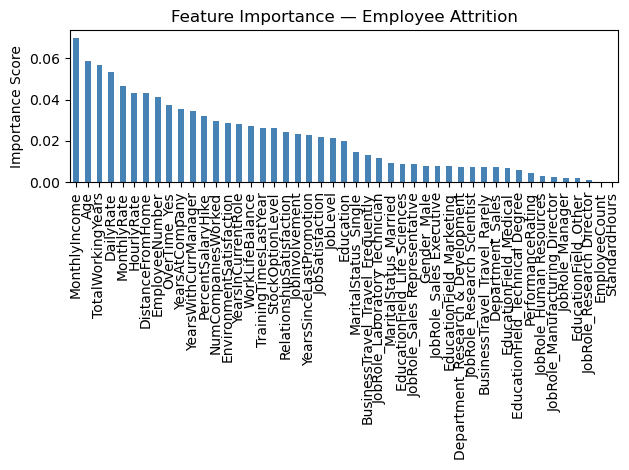

MonthlyIncome        0.069989
Age                  0.058582
TotalWorkingYears    0.056962
DailyRate            0.053236
MonthlyRate          0.046652
HourlyRate           0.043377
DistanceFromHome     0.043076
EmployeeNumber       0.041185
OverTime_Yes         0.037136
YearsAtCompany       0.035241
dtype: float64


In [33]:
importance.sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title("Feature Importance — Employee Attrition")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False).head(10))

In [34]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Train Accuracy : {train_acc:.2f}")
print(f"Test Accuracy  : {test_acc:.2f}")
print(f"Gap            : {train_acc - test_acc:.2f}")

print()

# Best n_estimators
for n in [10, 50, 100, 200, 500]:
    m = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    test_a = accuracy_score(y_test, m.predict(X_test))
    print(f"Trees: {n:4d}  ->  Test Accuracy: {test_a:.4f}")

Train Accuracy : 1.00
Test Accuracy  : 0.84
Gap            : 0.16

Trees:   10  ->  Test Accuracy: 0.8401
Trees:   50  ->  Test Accuracy: 0.8435
Trees:  100  ->  Test Accuracy: 0.8401
Trees:  200  ->  Test Accuracy: 0.8367
Trees:  500  ->  Test Accuracy: 0.8333


##Interesting finding — 50 trees is optimal for this dataset, not 100!